In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_file_name = r'D:\Users\macros\P29\BKIN\file.csv'

good_rows = []
header = None

try:
    with open(csv_file_name, 'r') as f:
        header = f.readline().strip().split(',')
        header = [h.strip() for h in header]

        for line in f:
            try:
                time_str = line.split(',')[0].strip()
                time_val = float(time_str)
                if np.isclose(time_val, round(time_val), atol=1e-9):
                    cleaned_line = [val.strip() for val in line.strip().split(',')]
                    good_rows.append(cleaned_line)

            except (ValueError, IndexError):
                continue

    data_filtered = pd.DataFrame(good_rows, columns=header)
    data_filtered = data_filtered.apply(pd.to_numeric)
    data_filtered = data_filtered.sort_values(by='Time').reset_index(drop=True)
    data_filtered = data_filtered.drop_duplicates(subset=['Time'], keep='first').reset_index(drop=True)

    print(f"Файл успешно отфильтрован. Количество строк: {len(data_filtered)}")

except FileNotFoundError:
    print(f"\nОШИБКА: Файл '{csv_file_name}' не найден.")
    exit()

Файл успешно отфильтрован. Количество строк: 221


In [69]:
exp_csv_file = r'D:\Users\macros\P29\exp.csv'

try:
    exp_data = pd.read_csv(exp_csv_file)
    print(f"Экспериментальные данные из файла '{exp_csv_file}' успешно загружены.")
    print(f"Количество строк в эксперименте: {len(exp_data)}")
    print("-----------------------------------------")
except FileNotFoundError:
    print(f"\nОШИБКА: Файл '{exp_csv_file}' не найден. Проверьте путь к файлу.")
    exit()


cols_to_convert = ['EZZ', 'ETT', 'ETZ']
for col in cols_to_convert:
    exp_data[col] = exp_data[col] / 100.0

exp_data.rename(columns={
    'SZZ': 'S_Y', 
    'STT': 'S_X', 
    'STZ': 'S_XY',
    'EZZ': 'EPTO_Y', 
    'ETT': 'EPTO_X', 
    'ETZ': 'EPTO_XY_'
}, inplace=True)
exp_data['EPTO_XY_'] = exp_data['EPTO_XY_'] / 2.0

# Расчет девиаторов
exp_data['e_xx'] = exp_data['EPTO_X']
exp_data['e_yy'] = exp_data['EPTO_Y']
exp_data['e_xy'] = exp_data['EPTO_XY_']

# Расчет векторов Ильюшина
exp_data['Eps_1_dev'] = exp_data['e_yy']
exp_data['Eps_2_dev'] = (1 / np.sqrt(3)) * (exp_data['e_yy'] + 2 * exp_data['e_xx'])
exp_data['Eps_3_dev'] = (2 / np.sqrt(3)) * exp_data['e_xy']

# Расчет длины дуги 's'
dEps1_exp = exp_data['Eps_1_dev'].diff().fillna(0)
dEps2_exp = exp_data['Eps_2_dev'].diff().fillna(0)
dEps3_exp = exp_data['Eps_3_dev'].diff().fillna(0)
ds_exp = np.sqrt(dEps1_exp**2 + dEps2_exp**2 + dEps3_exp**2)
exp_data['s'] = np.cumsum(ds_exp)

Экспериментальные данные из файла 'D:\Users\macros\P29\exp.csv' успешно загружены.
Количество строк в эксперименте: 104
-----------------------------------------


In [70]:
# Синхронизация шагов реального эксперимента с численным экспериментом

# Начало 2-го этапа деформирования численного эесперимента
time_split_calc = 20.0
start_index_calc = data_filtered['Time'].searchsorted(time_split_calc + 0.01, side='left')

# Начало 2-го этапа деформирования реального эесперимента
start_index_exp = (exp_data['EPTO_XY_'].abs() > 1e-5).to_numpy().nonzero()[0][0]

# Длины этапов в реальном эксперименте
num_points_stage1_exp = start_index_exp
num_points_stage2_exp = len(exp_data) - start_index_exp

# Конечное время расчета
time_end_calc = data_filtered['Time'].max()

time_sync_stage1 = np.linspace(0, time_split_calc, num_points_stage1_exp, endpoint=False)
time_sync_stage2 = np.linspace(time_split_calc, time_end_calc, num_points_stage2_exp)
time_sync_full = np.concatenate([time_sync_stage1, time_sync_stage2])
exp_data['Time_sync'] = time_sync_full

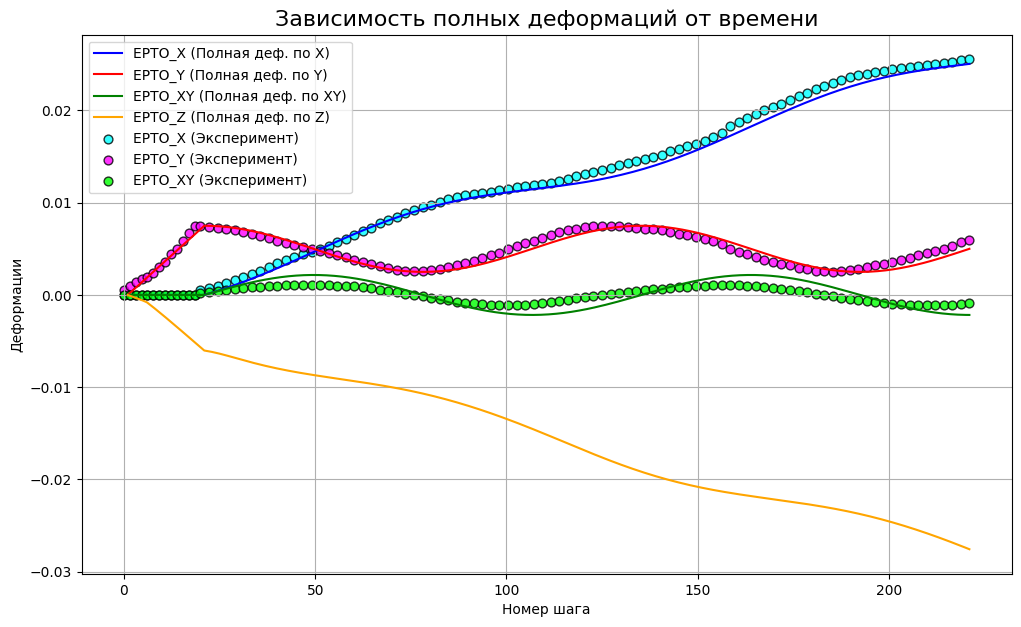

In [71]:
plt.figure(figsize=(12, 7))
plt.plot(data_filtered['Time'], data_filtered['EPTO_X'], label='EPTO_X (Полная деф. по X)', color='blue')
plt.plot(data_filtered['Time'], data_filtered['EPTO_Y'], label='EPTO_Y (Полная деф. по Y)', color='red')
plt.plot(data_filtered['Time'], data_filtered['EPTO_XY_'], label='EPTO_XY (Полная деф. по XY)', color='green')
plt.plot(data_filtered['Time'], data_filtered['EPTO_Z'], label='EPTO_Z (Полная деф. по Z)', color='orange')

plt.scatter(exp_data['Time_sync'], exp_data['EPTO_X'], 
            label='EPTO_X (Эксперимент)', color='cyan', marker='o', s=40, alpha=0.8, edgecolor='black')
    
plt.scatter(exp_data['Time_sync'], exp_data['EPTO_Y'], 
            label='EPTO_Y (Эксперимент)', color='magenta', marker='o', s=40, alpha=0.8, edgecolor='black')

plt.scatter(exp_data['Time_sync'], exp_data['EPTO_XY_'], 
            label='EPTO_XY (Эксперимент)', color='lime', marker='o', s=40, alpha=0.8, edgecolor='black')

plt.title('Зависимость полных деформаций от времени', fontsize=16)
plt.xlabel('Номер шага')
plt.ylabel('Деформации')
plt.grid(True)
plt.legend()

plt.show()

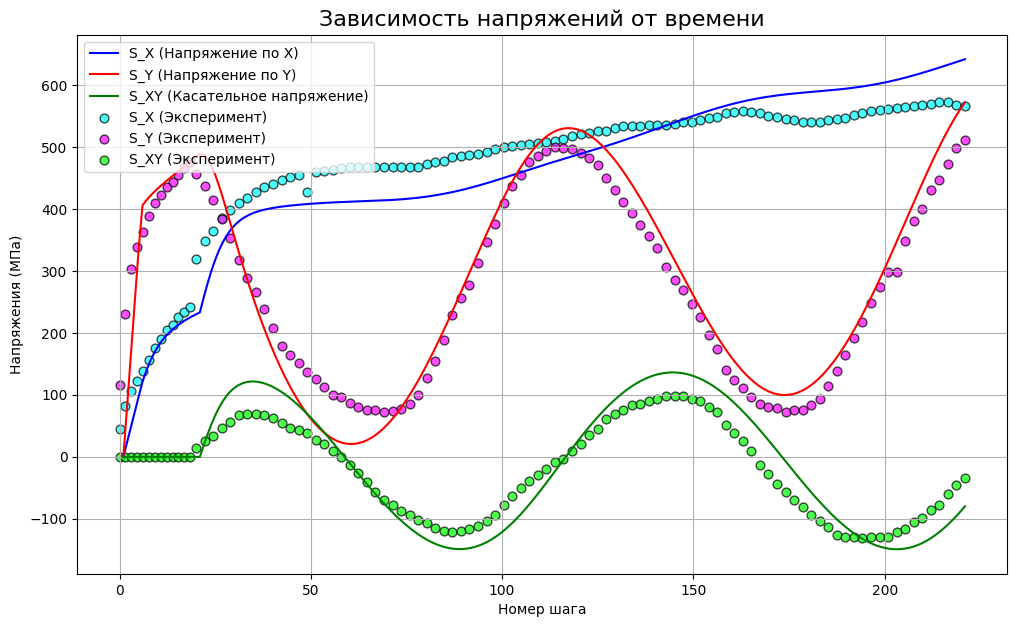

In [72]:
plt.figure(figsize=(12, 7))
plt.plot(data_filtered['Time'], data_filtered['S_X'], label='S_X (Напряжение по X)', color='blue')
plt.plot(data_filtered['Time'], data_filtered['S_Y'], label='S_Y (Напряжение по Y)', color='red')
plt.plot(data_filtered['Time'], data_filtered['S_XY'], label='S_XY (Касательное напряжение)', color='green')

plt.scatter(exp_data['Time_sync'], exp_data['S_X'], 
            label='S_X (Эксперимент)', color='cyan', marker='o', s=40, alpha=0.7, edgecolor='black')

plt.scatter(exp_data['Time_sync'], exp_data['S_Y'], 
            label='S_Y (Эксперимент)', color='magenta', marker='o', s=40, alpha=0.7, edgecolor='black')

plt.scatter(exp_data['Time_sync'], exp_data['S_XY'], 
            label='S_XY (Эксперимент)', color='lime', marker='o', s=40, alpha=0.7, edgecolor='black')

plt.title('Зависимость напряжений от времени', fontsize=16)
plt.xlabel('Номер шага')
plt.ylabel('Напряжения (МПа)')
plt.grid(True)
plt.legend()

plt.show()

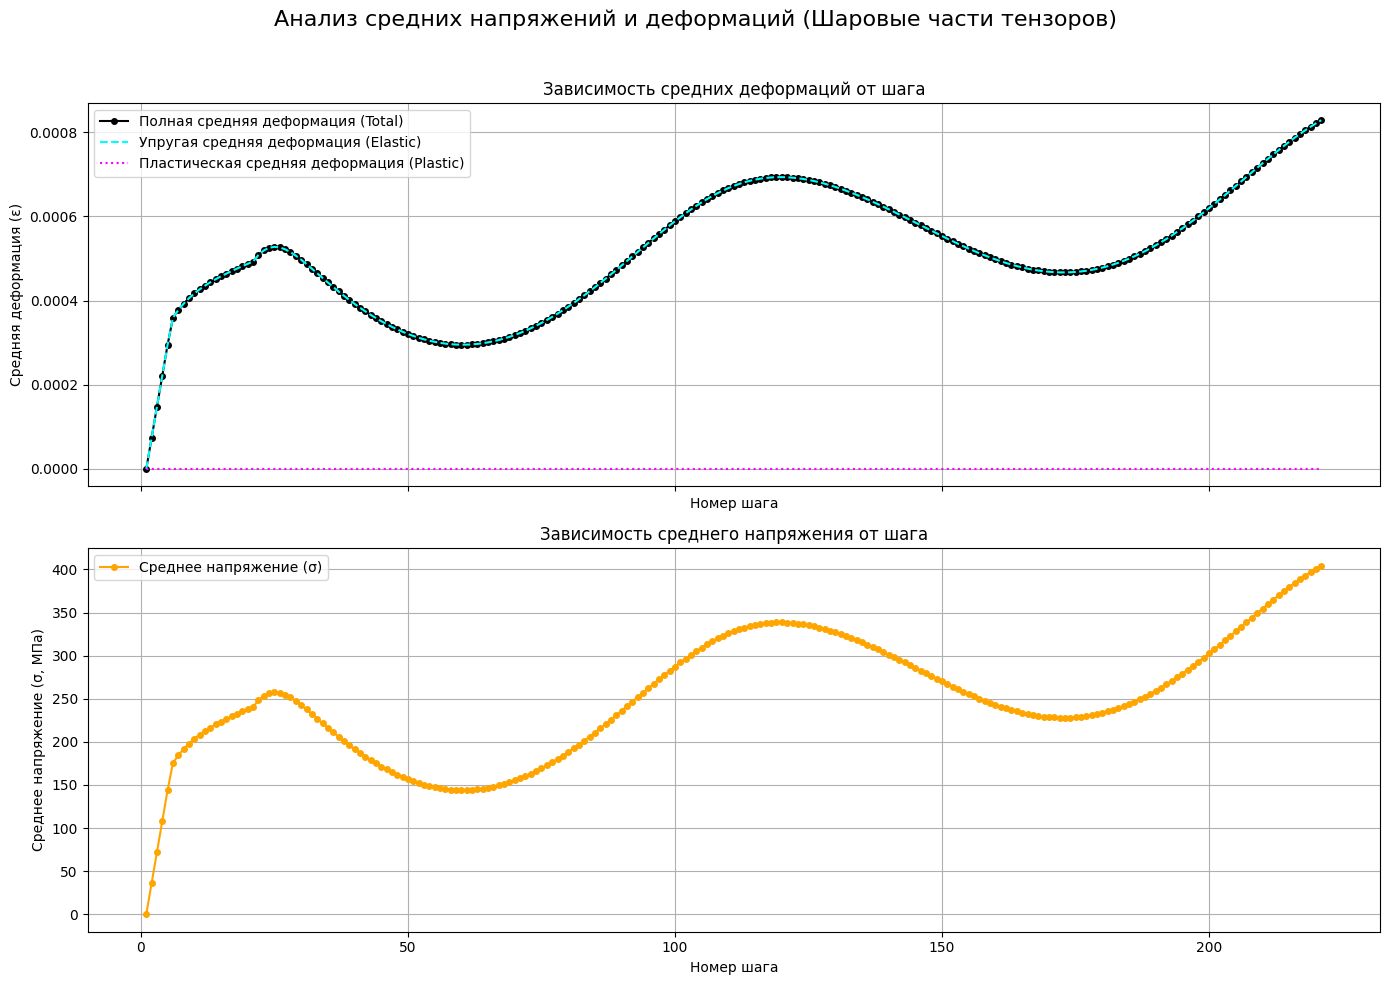

In [73]:
required_cols = ['S_X', 'S_Y', 'EPTO_X', 'EPTO_Y', 'EPTO_Z', 
                 'EPEL_X', 'EPEL_Y', 'EPEL_Z', 'EPPL_X', 'EPPL_Y', 'EPPL_Z']
if not all(col in data_filtered.columns for col in required_cols):
    print("ОШИБКА: В данных отсутствуют необходимые столбцы для расчета.")
else:
    data_filtered['Mean_Stress'] = (1/3) * (data_filtered['S_X'] + data_filtered['S_Y'] + 0)
    data_filtered['Mean_Deformation_Total'] = (1/3) * (data_filtered['EPTO_X'] + data_filtered['EPTO_Y'] + data_filtered['EPTO_Z'])
    data_filtered['Mean_Deformation_Elastic'] = (1/3) * (data_filtered['EPEL_X'] + data_filtered['EPEL_Y'] + data_filtered['EPEL_Z'])
    data_filtered['Mean_Deformation_Plastic'] = (1/3) * (data_filtered['EPPL_X'] + data_filtered['EPPL_Y'] + data_filtered['EPPL_Z'])
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    fig.suptitle('Анализ средних напряжений и деформаций (Шаровые части тензоров)', fontsize=16)

    axes[0].plot(data_filtered['Time'], data_filtered['Mean_Deformation_Total'], label='Полная средняя деформация (Total)', color='black', marker='o', markersize=4)
    axes[0].plot(data_filtered['Time'], data_filtered['Mean_Deformation_Elastic'], label='Упругая средняя деформация (Elastic)', color='cyan', linestyle='--')
    axes[0].plot(data_filtered['Time'], data_filtered['Mean_Deformation_Plastic'], label='Пластическая средняя деформация (Plastic)', color='magenta', linestyle=':')
    
    axes[0].set_title('Зависимость средних деформаций от шага')
    axes[0].set_ylabel('Средняя деформация (ε)')
    axes[0].set_xlabel('Номер шага')
    axes[0].grid(True)
    axes[0].legend()


    axes[1].plot(data_filtered['Time'], data_filtered['Mean_Stress'], label='Среднее напряжение (σ)', color='orange', marker='o', markersize=4)
    
    axes[1].set_title('Зависимость среднего напряжения от шага')
    axes[1].set_xlabel('Номер шага')
    axes[1].set_ylabel('Среднее напряжение (σ, МПа)')
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

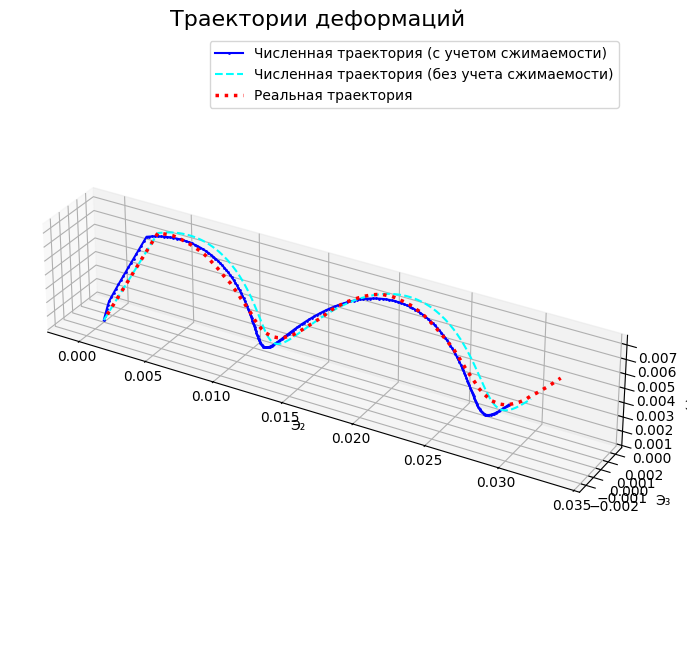

In [79]:
if 'Mean_Deformation_Total' not in data_filtered.columns:
    print("ОШИБКА: Сначала выполните ячейку с расчетом средних деформаций ('Mean_Deformation_Total').")
else:
    # Вычисляем компоненты девиатора
    # Для диагональных компонент: e_ii = epsilon_ii - Mean_Deformation_Total
    data_filtered['e_xx'] = data_filtered['EPTO_X'] - data_filtered['Mean_Deformation_Total']
    data_filtered['e_yy'] = data_filtered['EPTO_Y'] - data_filtered['Mean_Deformation_Total']
    data_filtered['e_zz'] = data_filtered['EPTO_Z'] - data_filtered['Mean_Deformation_Total']

    # Для недиагональных компонент девиатор совпадает с исходным тензором
    data_filtered['e_xy'] = data_filtered['EPTO_XY_']

    assert np.allclose(data_filtered['e_xx'] + data_filtered['e_yy'] + data_filtered['e_zz'], 0, atol=1e-9), \
        "Проверка провалена: След девиатора деформаций не равен нулю!"




    # ВЫЧИСЛЕНИЕ КОМПОНЕНТ ВЕКТОРА ДЕФОРМАЦИЙ ИЛЬЮШИНА (по формуле 1.1.2)
    data_filtered['Eps_1_dev'] = data_filtered['e_yy']
    data_filtered['Eps_2_dev'] = (1 / np.sqrt(3)) * (data_filtered['e_yy'] + 2 * data_filtered['e_xx'])
    data_filtered['Eps_3_dev'] = (2 / np.sqrt(3)) * data_filtered['e_xy']

    # КОМПОНЕНТ ВЕКТОРА ДЕФОРМАЦИЙ ИЛЬЮШИНА, игнорируя шаровую часть, как будто материал идеально несжимаем
    data_filtered['Eps_1_ideal'] = data_filtered['EPTO_Y']
    data_filtered['Eps_2_ideal'] = (1 / np.sqrt(3)) * (data_filtered['EPTO_Y'] + 2 * data_filtered['EPTO_X'])
    data_filtered['Eps_3_ideal'] = (2 / np.sqrt(3)) * data_filtered['EPTO_XY_']


    
    from mpl_toolkits.mplot3d import Axes3D

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    x_data_dev = data_filtered['Eps_2_dev']
    y_data_dev = data_filtered['Eps_3_dev']
    z_data_dev = data_filtered['Eps_1_dev']
    ax.plot(x_data_dev, y_data_dev, z_data_dev, 
            color='blue', marker='.', markersize=2, label='Численная траектория (с учетом сжимаемости)')

    x_data_ideal = data_filtered['Eps_2_ideal']
    y_data_ideal = data_filtered['Eps_3_ideal']
    z_data_ideal = data_filtered['Eps_1_ideal']
    ax.plot(x_data_ideal, y_data_ideal, z_data_ideal, 
            color='cyan', linestyle='--', label='Численная траектория (без учета сжимаемости)')
    
    ax.plot(exp_data['Eps_2_dev'], exp_data['Eps_3_dev'], exp_data['Eps_1_dev'], 
            color='red', linewidth=2.5, linestyle=':', label='Реальная траектория')
    

    ax.set_title('Траектории деформаций', fontsize=16)
    ax.set_xlabel('Э₂')
    ax.set_ylabel('Э₃')
    ax.set_zlabel('Э₁')
    ax.legend()
    ax.grid(True)
    ax.set_aspect('equal')

    plt.show()

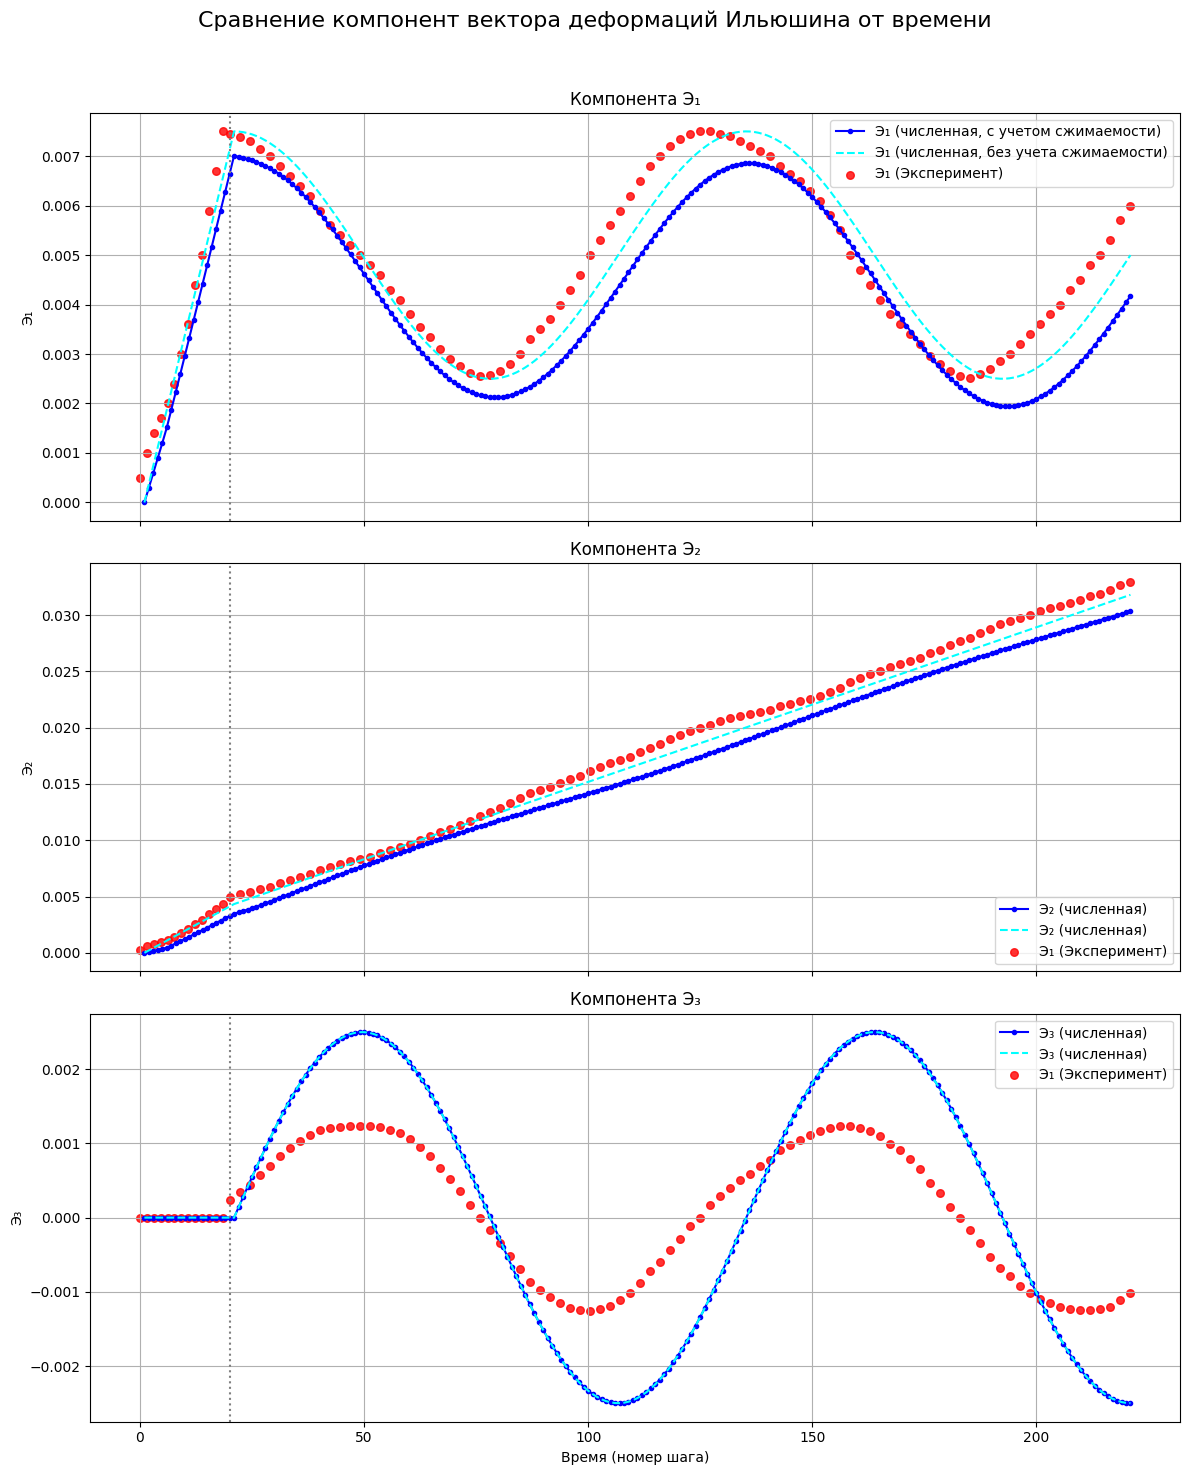


A. СРАВНЕНИЕ: РАСЧЕТ 'ЧИСЛЕННЫЙ' (СЖИМАЕМЫЙ) vs ЭКСПЕРИМЕНТ
--- Компонента Э₁ (Численный vs Эксперимент) ---
  Средняя относительная ошибка: 15.35 %
  Максимальная относительная ошибка: 40.64 %
  Минимальная относительная ошибка: 0.02 %
--- Компонента Э₂ (Численный vs Эксперимент) ---
  Средняя относительная ошибка: 10.10 %
  Максимальная относительная ошибка: 31.17 %
  Минимальная относительная ошибка: 5.13 %
--- Компонента Э₃ (Численный vs Эксперимент) ---
  Средняя относительная ошибка: 736.01 %
  Максимальная относительная ошибка: 57396.67 %
  Минимальная относительная ошибка: 2.40 %

B. СРАВНЕНИЕ: РАСЧЕТ 'ЧИСЛЕННЫЙ' (НЕСЖИМАЕМЫЙ) vs ЭКСПЕРИМЕНТ
--- Компонента Э₁ (Численный vs Эксперимент) ---
  Средняя относительная ошибка: 10.04 %
  Максимальная относительная ошибка: 23.26 %
  Минимальная относительная ошибка: 0.22 %
--- Компонента Э₂ (Численный vs Эксперимент) ---
  Средняя относительная ошибка: 4.31 %
  Максимальная относительная ошибка: 14.26 %
  Минимальная относительная оши

In [88]:
# %%
# --- СРАВНЕНИЕ КОМПОНЕНТ ВЕКТОРОВ ДЕФОРМАЦИЙ (ГРАФИКИ + АНАЛИТИКА) ---

required_cols = ['Time', 'Eps_1_dev', 'Eps_2_dev', 'Eps_3_dev', 
                 'Eps_1_ideal', 'Eps_2_ideal', 'Eps_3_ideal']
if not all(col in data_filtered.columns for col in required_cols):
    print("ОШИБКА: Сначала выполните ячейку с расчетом 'реальных' и 'идеальных' векторов Ильюшина.")
else:
    # --- БЛОК ВИЗУАЛИЗАЦИИ (без изменений) ---
    fig, axes = plt.subplots(3, 1, figsize=(12, 15), sharex=True)
    fig.suptitle('Сравнение компонент вектора деформаций Ильюшина от времени', fontsize=16)

    # График для Э₁
    axes[0].plot(data_filtered['Time'], data_filtered['Eps_1_dev'], color='blue', label='Э₁ (численная, с учетом сжимаемости)', marker='.')
    axes[0].plot(data_filtered['Time'], data_filtered['Eps_1_ideal'], color='cyan', label='Э₁ (численная, без учета сжимаемости)', linestyle='--')
    axes[0].scatter(exp_data['Time_sync'], exp_data['Eps_1_dev'], color='red', marker='o', s=30, label='Э₁ (Эксперимент)', alpha=0.8)
    axes[0].set_title('Компонента Э₁'); axes[0].set_ylabel('Э₁'); axes[0].grid(True); axes[0].legend()
    axes[0].axvline(x=20, color='gray', linestyle=':')

    # График для Э₂
    axes[1].plot(data_filtered['Time'], data_filtered['Eps_2_dev'], color='blue', label='Э₂ (численная)', marker='.')
    axes[1].plot(data_filtered['Time'], data_filtered['Eps_2_ideal'], color='cyan', label='Э₂ (численная)', linestyle='--')
    axes[1].scatter(exp_data['Time_sync'], exp_data['Eps_2_dev'], color='red', marker='o', s=30, label='Э₁ (Эксперимент)', alpha=0.8)
    axes[1].set_title('Компонента Э₂'); axes[1].set_ylabel('Э₂'); axes[1].grid(True); axes[1].legend()
    axes[1].axvline(x=20, color='gray', linestyle=':')

    # График для Э₃
    axes[2].plot(data_filtered['Time'], data_filtered['Eps_3_dev'], color='blue', label='Э₃ (численная)', marker='.')
    axes[2].plot(data_filtered['Time'], data_filtered['Eps_3_ideal'], color='cyan', label='Э₃ (численная)', linestyle='--')
    axes[2].scatter(exp_data['Time_sync'], exp_data['Eps_3_dev'], color='red', marker='o', s=30, label='Э₁ (Эксперимент)', alpha=0.8)
    axes[2].set_title('Компонента Э₃'); axes[2].set_xlabel('Время (номер шага)'); axes[2].set_ylabel('Э₃'); axes[2].grid(True); axes[2].legend()
    axes[2].axvline(x=20, color='gray', linestyle=':')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    
    # !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
    # ЧИСЛЕННАЯ АНАЛИТИКА РАСХОЖДЕНИЙ
    # !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
    from scipy.interpolate import interp1d

    # Создаем функции-интерполяторы для каждой компоненты эксперимента
    interp_eps1_exp = interp1d(exp_data['Time_sync'], exp_data['Eps_1_dev'], fill_value="extrapolate")
    interp_eps2_exp = interp1d(exp_data['Time_sync'], exp_data['Eps_2_dev'], fill_value="extrapolate")
    interp_eps3_exp = interp1d(exp_data['Time_sync'], exp_data['Eps_3_dev'], fill_value="extrapolate")

    # Вычисляем значения экспериментальных кривых в тех же точках времени, что и в расчете
    eps1_exp_interp = interp_eps1_exp(data_filtered['Time'])
    eps2_exp_interp = interp_eps2_exp(data_filtered['Time'])
    eps3_exp_interp = interp_eps3_exp(data_filtered['Time'])

    # Добавляем интерполированные данные в наш основной DataFrame для удобства
    data_filtered['Eps_1_exp_interp'] = eps1_exp_interp
    data_filtered['Eps_2_exp_interp'] = eps2_exp_interp
    data_filtered['Eps_3_exp_interp'] = eps3_exp_interp

    def calculate_and_print_stats(calc_series, exp_series, model_name, component_name):
        """Рассчитывает и выводит статистику расхождений."""
        mask = exp_series.abs() > 1e-6
        
        if not mask.any():
            return

        # Вычисляем относительную ошибку в % только для значимых точек
        relative_error_percent = ((calc_series[mask] - exp_series[mask]).abs() / exp_series[mask].abs()) * 100
        
        print(f"--- {component_name} ({model_name} vs Эксперимент) ---")
        print(f"  Средняя относительная ошибка: {relative_error_percent.mean():.2f} %")
        print(f"  Максимальная относительная ошибка: {relative_error_percent.max():.2f} %")
        print(f"  Минимальная относительная ошибка: {relative_error_percent.min():.2f} %")


    stage2_data = data_filtered[data_filtered['Time'] > 20].copy()
    print("\n" + "="*80)
    print("A. СРАВНЕНИЕ: РАСЧЕТ 'ЧИСЛЕННЫЙ' (СЖИМАЕМЫЙ) vs ЭКСПЕРИМЕНТ")
    print("="*80)
    calculate_and_print_stats(stage2_data['Eps_1_dev'], stage2_data['Eps_1_exp_interp'], "Численный", "Компонента Э₁")
    calculate_and_print_stats(stage2_data['Eps_2_dev'], stage2_data['Eps_2_exp_interp'], "Численный", "Компонента Э₂")
    calculate_and_print_stats(stage2_data['Eps_3_dev'], stage2_data['Eps_3_exp_interp'], "Численный", "Компонента Э₃")

    print("\n" + "="*80)
    print("B. СРАВНЕНИЕ: РАСЧЕТ 'ЧИСЛЕННЫЙ' (НЕСЖИМАЕМЫЙ) vs ЭКСПЕРИМЕНТ")
    print("="*80)
    calculate_and_print_stats(stage2_data['Eps_1_ideal'], stage2_data['Eps_1_exp_interp'], "Численный", "Компонента Э₁")
    calculate_and_print_stats(stage2_data['Eps_2_ideal'], stage2_data['Eps_2_exp_interp'], "Численный", "Компонента Э₂")
    calculate_and_print_stats(stage2_data['Eps_3_ideal'], stage2_data['Eps_3_exp_interp'], "Численный", "Компонента Э₃")

    print("\n" + "="*80)

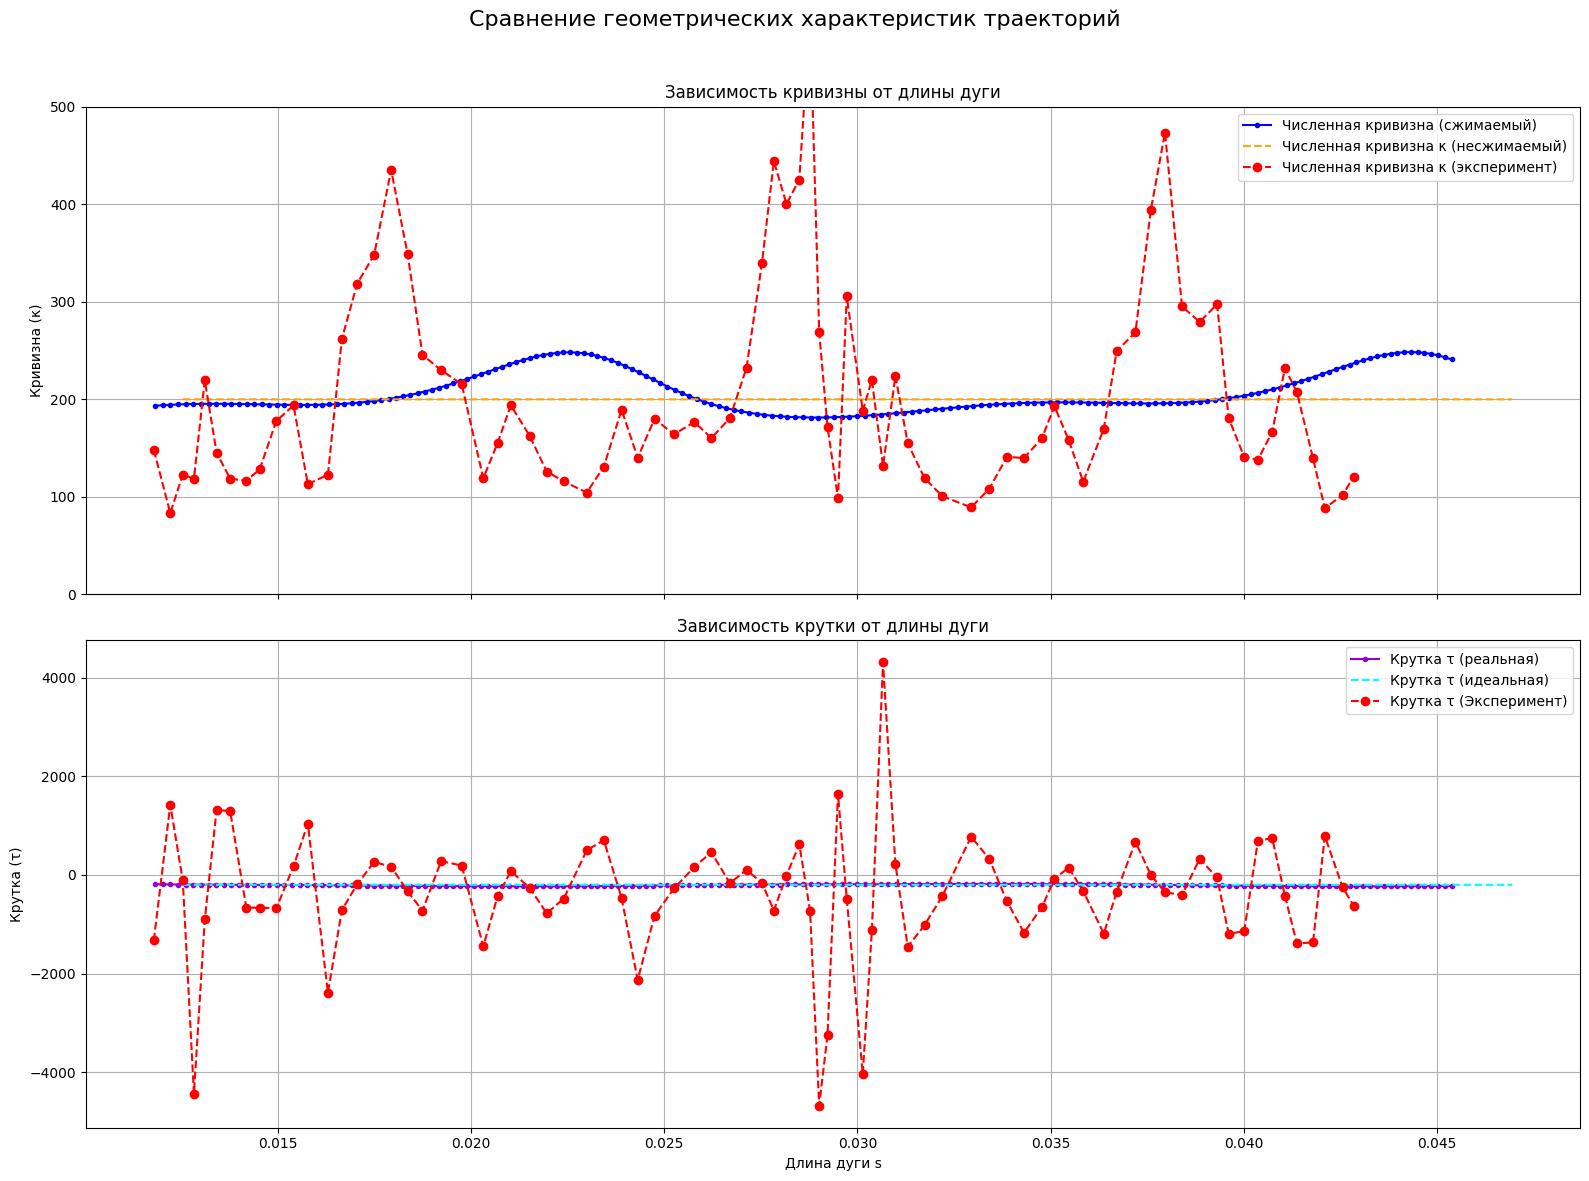

In [96]:
# РАСЧЕТ ДЛИНЫ ДУГИ 's' И ДИФФЕРЕНЦИРОВАНИЕ ВЕКТОРА ДЕФОРМАЦИЙ

required_cols = ['Eps_1_dev', 'Eps_2_dev', 'Eps_3_dev', 'Eps_1_ideal', 'Eps_2_ideal', 'Eps_3_ideal']
if not all(col in data_filtered.columns for col in required_cols):
    print("ОШИБКА: Сначала выполните ячейку с расчетом 'реальных' и 'идеальных' векторов Ильюшина.")
else:
    # ВЫЧИСЛЕНИЕ ДЛИНЫ ДУГИ 's'
    
    # Считаем приращения компонент вектора деформаций (dЭ) на каждом шаге
    # .diff() вычисляет разницу между текущим и предыдущим элементом
    # .fillna(0) заменяет все значения NaN нулем
    dEps1_dev = data_filtered['Eps_1_dev'].diff().fillna(0)
    dEps2_dev = data_filtered['Eps_2_dev'].diff().fillna(0)
    dEps3_dev = data_filtered['Eps_3_dev'].diff().fillna(0)

    # Длина элементарного сегмента траектории: ds = sqrt(dЭ1^2 + dЭ2^2 + dЭ3^2)
    ds_dev = np.sqrt(dEps1_dev**2 + dEps2_dev**2 + dEps3_dev**2)

    # Полная длина дуги s как накопленная сумма (интеграл)
    data_filtered['s_dev'] = np.cumsum(ds_dev)

    
    # ДИФФЕРЕНЦИРОВАНИЕ ВЕКТОРА ДЕФОРМАЦИЙ ПО ДЛИНЕ ДУГИ 's'
    
    # Подготавливаем данные для дифференцирования:
    # Вектор деформаций Э(s)
    Eps_vec_dev = data_filtered[['Eps_1_dev', 'Eps_2_dev', 'Eps_3_dev']].values
    # Параметр дифференцирования s
    s_param_dev = data_filtered['s_dev'].values

    # Вычисляем первую производную Э'= dЭ/ds с помощью центральных разностей
    # Э'(tᵢ) ≈ (Э(tᵢ₊₁) - Э(tᵢ₋₁)) / (s(tᵢ₊₁) - s(tᵢ₋₁))
    Eps_dot_dev = np.gradient(Eps_vec_dev, s_param_dev, axis=0, edge_order=2)
    data_filtered['Eps_1_dot_dev'] = Eps_dot_dev[:, 0]
    data_filtered['Eps_2_dot_dev'] = Eps_dot_dev[:, 1]
    data_filtered['Eps_3_dot_dev'] = Eps_dot_dev[:, 2]
    
    # Вычисляем вторую производную Э'' = d(Э')/ds
    Eps_dot_dot_dev = np.gradient(Eps_dot_dev, s_param_dev, axis=0, edge_order=2)

    # Вычисляем третью производную Э'''= d(Э'')/ds
    Eps_dot_dot_dot_dev = np.gradient(Eps_dot_dot_dev, s_param_dev, axis=0, edge_order=2)
    
    # РАСЧЕТ КРИВИЗНЫ (κ)
    # Формула: κ = |Э' × Э''| / |Э̇|³
    cross_product_12_dev = np.cross(Eps_dot_dev, Eps_dot_dot_dev)
    norm_Eps_dot_dev = np.linalg.norm(Eps_dot_dev, axis=1)
    norm_cross_product_12_dev = np.linalg.norm(cross_product_12_dev, axis=1)
    data_filtered['curvature_dev'] = np.divide(norm_cross_product_12_dev, norm_Eps_dot_dev**3, where=norm_Eps_dot_dev > 1e-9)

    # РАСЧЕТ КРУТКИ (τ)
    # Формула: τ = (Э'× Э'') ⋅ Э''' / |Э'× Э''|²
    mixed_product_dev = np.sum(cross_product_12_dev * Eps_dot_dot_dot_dev, axis=1)
    data_filtered['torsion_dev'] = np.divide(mixed_product_dev, norm_cross_product_12_dev**2, where=norm_cross_product_12_dev > 1e-9)

    # РАСЧЕТ длины траеткории деформации для несжимаемого материала
    dEps1_ideal = data_filtered['Eps_1_ideal'].diff().fillna(0)
    dEps2_ideal = data_filtered['Eps_2_ideal'].diff().fillna(0)
    dEps3_ideal = data_filtered['Eps_3_ideal'].diff().fillna(0)
    ds_ideal = np.sqrt(dEps1_ideal**2 + dEps2_ideal**2 + dEps3_ideal**2)
    data_filtered['s_ideal'] = np.cumsum(ds_ideal)

    Eps_vec_ideal = data_filtered[['Eps_1_ideal', 'Eps_2_ideal', 'Eps_3_ideal']].values
    s_param_ideal = data_filtered['s_ideal'].values
    Eps_dot_ideal = np.gradient(Eps_vec_ideal, s_param_ideal, axis=0, edge_order=2)
    data_filtered['Eps_1_dot_ideal'] = Eps_dot_ideal[:, 0]
    data_filtered['Eps_2_dot_ideal'] = Eps_dot_ideal[:, 1]
    data_filtered['Eps_3_dot_ideal'] = Eps_dot_ideal[:, 2]
    Eps_dot_dot_ideal = np.gradient(Eps_dot_ideal, s_param_ideal, axis=0, edge_order=2)
    Eps_dot_dot_dot_ideal = np.gradient(Eps_dot_dot_ideal, s_param_ideal, axis=0, edge_order=2)

    cross_product_12_ideal = np.cross(Eps_dot_ideal, Eps_dot_dot_ideal)
    norm_Eps_dot_ideal = np.linalg.norm(Eps_dot_ideal, axis=1)
    norm_cross_product_12_ideal = np.linalg.norm(cross_product_12_ideal, axis=1)
    data_filtered['curvature_ideal'] = np.divide(norm_cross_product_12_ideal, norm_Eps_dot_ideal**3, where=norm_Eps_dot_ideal > 1e-9)
    mixed_product_ideal = np.sum(cross_product_12_ideal * Eps_dot_dot_dot_ideal, axis=1)
    data_filtered['torsion_ideal'] = np.divide(mixed_product_ideal, norm_cross_product_12_ideal**2, where=norm_cross_product_12_ideal > 1e-9)

    # РАСЧЕТ длины траеткории деформации для эксперимента
    dEps1_exp = exp_data['Eps_1_dev'].diff().fillna(0)
    dEps2_exp = exp_data['Eps_2_dev'].diff().fillna(0)
    dEps3_exp = exp_data['Eps_3_dev'].diff().fillna(0)
    ds_exp = np.sqrt(dEps1_exp**2 + dEps2_exp**2 + dEps3_exp**2)
    exp_data['s_exp'] = np.cumsum(ds_exp)

    Eps_vec_exp = exp_data[['Eps_1_dev', 'Eps_2_dev', 'Eps_3_dev']].values
    s_param_exp = exp_data['s_exp'].values
    Eps_dot_exp = np.gradient(Eps_vec_exp, s_param_exp, axis=0, edge_order=2)
    Eps_dot_dot_exp = np.gradient(Eps_dot_exp, s_param_exp, axis=0, edge_order=2)
    Eps_dot_dot_dot_exp = np.gradient(Eps_dot_dot_exp, s_param_exp, axis=0, edge_order=2)
    cross_product_12_exp = np.cross(Eps_dot_exp, Eps_dot_dot_exp)
    norm_Eps_dot_exp = np.linalg.norm(Eps_dot_exp, axis=1)
    norm_cross_product_12_exp = np.linalg.norm(cross_product_12_exp, axis=1)
    exp_data['curvature_exp'] = np.divide(norm_cross_product_12_exp, norm_Eps_dot_exp**3, where=norm_Eps_dot_exp > 1e-9)
    mixed_product_exp = np.sum(cross_product_12_exp * Eps_dot_dot_dot_exp, axis=1)
    exp_data['torsion_exp'] = np.divide(mixed_product_exp, norm_cross_product_12_exp**2, where=norm_cross_product_12_exp > 1e-9)


    fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)
    fig.suptitle('Сравнение геометрических характеристик траекторий', fontsize=16)

    plot_data = data_filtered.iloc[start_index_calc + 20 : -3]

    start_index_exp = exp_data['Time_sync'].searchsorted(20.01, side='left')
    plot_data_exp = exp_data.iloc[start_index_exp + 8 : -3]

    axes[0].plot(plot_data['s_dev'], plot_data['curvature_dev'], color='blue', label='Численная кривизна (сжимаемый)', marker='.')
    axes[0].plot(plot_data['s_ideal'], plot_data['curvature_ideal'], color='orange', label='Численная кривизна κ (несжимаемый)', linestyle='--')
    axes[0].plot(plot_data_exp['s_exp'], plot_data_exp['curvature_exp'], color='red', label='Численная кривизна κ (эксперимент)', marker='o', linestyle='--')
    axes[0].set_title('Зависимость кривизны от длины дуги')
    axes[0].set_ylabel('Кривизна (κ)')
    axes[0].grid(True)
    axes[0].legend()
    axes[0].set_ylim(0, 500)

    axes[1].plot(plot_data['s_dev'], plot_data['torsion_dev'], color='darkviolet', label='Крутка τ (реальная)', marker='.')
    axes[1].plot(plot_data['s_ideal'], plot_data['torsion_ideal'], color='cyan', label='Крутка τ (идеальная)', linestyle='--')
    axes[1].plot(plot_data_exp['s_exp'], plot_data_exp['torsion_exp'], color='red', label='Крутка τ (Эксперимент)', marker='o', linestyle='--')
    axes[1].set_title('Зависимость крутки от длины дуги')
    axes[1].set_xlabel('Длина дуги s')
    axes[1].set_ylabel('Крутка (τ)')
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    

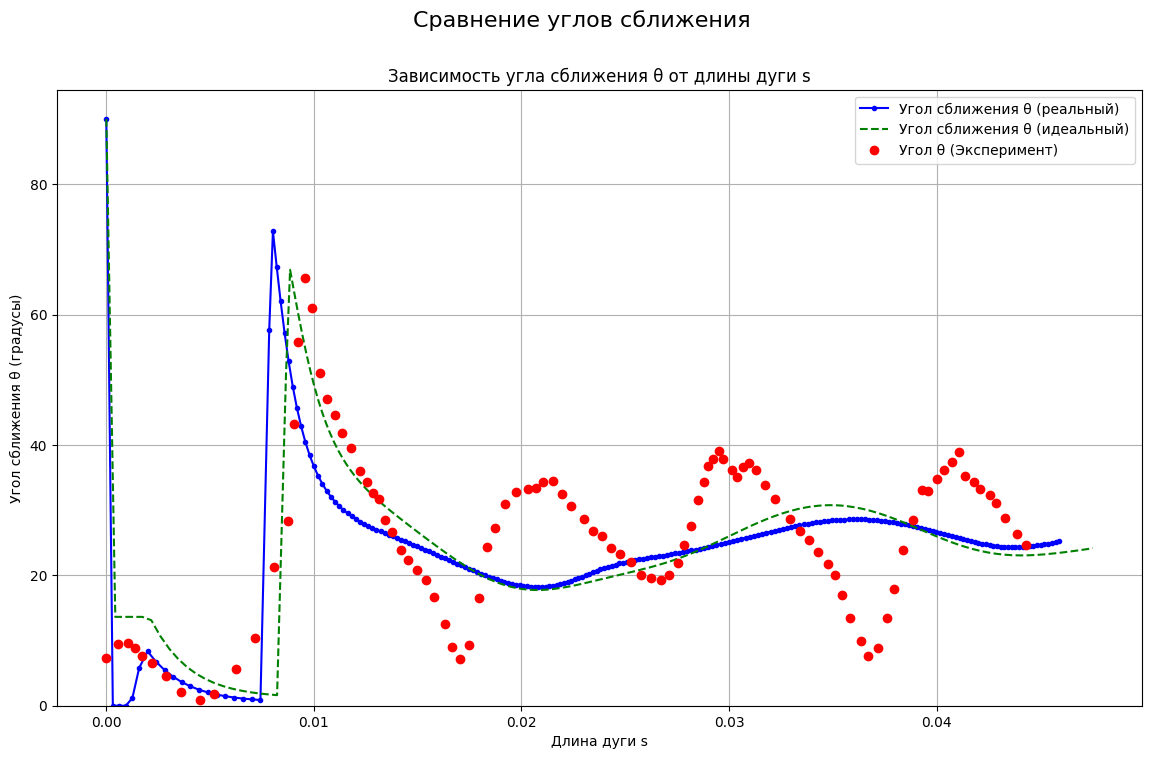

In [98]:
required_cols = [
    's_dev', 's_ideal', 'S_X', 'S_Y', 'S_XY', 
    'Eps_1_dot_dev', 'Eps_2_dot_dev', 'Eps_3_dot_dev',
    'Eps_1_dot_ideal', 'Eps_2_dot_ideal', 'Eps_3_dot_ideal'
]
if not all(col in data_filtered.columns for col in required_cols):
    print("ОШИБКА: Не хватает необходимых столбцов.")
    print("Убедитесь, что ячейка с расчетом производных ('Eps_1_dot' и т.д.) была успешно выполнена.")
else:
    # Расчет компонент вектора напряжений Ильюшина
    data_filtered['sigma_1'] = data_filtered['S_Y'] - 0.5 * data_filtered['S_X']
    data_filtered['sigma_2'] = (np.sqrt(3) / 2) * data_filtered['S_X']
    data_filtered['sigma_3'] = np.sqrt(3) * data_filtered['S_XY']
    sigma_vec = data_filtered[['sigma_1', 'sigma_2', 'sigma_3']].values
    norm_sigma = np.linalg.norm(sigma_vec, axis=1)

    # Вычисление угла сближения
    Eps_dot_vec_dev = data_filtered[['Eps_1_dot_dev', 'Eps_2_dot_dev', 'Eps_3_dot_dev']].values
    norm_Eps_dot_dev = np.linalg.norm(Eps_dot_vec_dev, axis=1)
    dot_product_dev = np.sum(sigma_vec * Eps_dot_vec_dev, axis=1)
    cos_theta_dev = np.clip(np.divide(dot_product_dev, norm_sigma * norm_Eps_dot_dev, where=(norm_sigma * norm_Eps_dot_dev) > 1e-9), -1.0, 1.0)
    data_filtered['theta_deg_dev'] = np.degrees(np.arccos(cos_theta_dev))

    Eps_dot_vec_ideal = data_filtered[['Eps_1_dot_ideal', 'Eps_2_dot_ideal', 'Eps_3_dot_ideal']].values
    norm_Eps_dot_ideal = np.linalg.norm(Eps_dot_vec_ideal, axis=1)
    dot_product_ideal = np.sum(sigma_vec * Eps_dot_vec_ideal, axis=1)
    cos_theta_ideal = np.clip(np.divide(dot_product_ideal, norm_sigma * norm_Eps_dot_ideal, where=(norm_sigma * norm_Eps_dot_ideal) > 1e-9), -1.0, 1.0)
    data_filtered['theta_deg_ideal'] = np.degrees(np.arccos(cos_theta_ideal))


    # Расчет вектора напряжений Ильюшина для эксперимента
    exp_data['sigma_1'] = exp_data['S_Y'] - 0.5 * exp_data['S_X']
    exp_data['sigma_2'] = (np.sqrt(3) / 2) * exp_data['S_X']
    exp_data['sigma_3'] = np.sqrt(3) * exp_data['S_XY']
    sigma_vec_exp = exp_data[['sigma_1', 'sigma_2', 'sigma_3']].values
    norm_sigma_exp = np.linalg.norm(sigma_vec_exp, axis=1)

    # Расчет производной от СГЛАЖЕННЫХ экспериментальных данных
    from scipy.signal import savgol_filter
    window_length = 11
    polyorder = 3
    exp_data['Eps_1_smooth'] = savgol_filter(exp_data['Eps_1_dev'], window_length, polyorder)
    exp_data['Eps_2_smooth'] = savgol_filter(exp_data['Eps_2_dev'], window_length, polyorder)
    exp_data['Eps_3_smooth'] = savgol_filter(exp_data['Eps_3_dev'], window_length, polyorder)
    Eps_vec_exp_smooth = exp_data[['Eps_1_smooth', 'Eps_2_smooth', 'Eps_3_smooth']].values
    s_param_exp = exp_data['s'].values
    Eps_dot_exp = np.gradient(Eps_vec_exp_smooth, s_param_exp, axis=0, edge_order=2)

    # Расчет угла для эксперимента
    norm_Eps_dot_exp = np.linalg.norm(Eps_dot_exp, axis=1)
    dot_product_exp = np.sum(sigma_vec_exp * Eps_dot_exp, axis=1)
    cos_theta_exp = np.clip(np.divide(dot_product_exp, norm_sigma_exp * norm_Eps_dot_exp, where=(norm_sigma_exp * norm_Eps_dot_exp) > 1e-9), -1.0, 1.0)
    exp_data['theta_deg_exp'] = np.degrees(np.arccos(cos_theta_exp))

    fig, ax = plt.subplots(figsize=(14, 8))
    fig.suptitle('Сравнение углов сближения', fontsize=16)

    ax.plot(data_filtered['s_dev'], data_filtered['theta_deg_dev'], color='blue', label='Угол сближения θ (реальный)', marker='.')
    ax.plot(data_filtered['s_ideal'], data_filtered['theta_deg_ideal'], color='green', label='Угол сближения θ (идеальный)', linestyle='--')
    ax.plot(exp_data['s'], exp_data['theta_deg_exp'], color='red', label='Угол θ (Эксперимент)', marker='o', linestyle='None') # Эксперимент точками
    
    ax.set_title('Зависимость угла сближения θ от длины дуги s')
    ax.set_xlabel('Длина дуги s')
    ax.set_ylabel('Угол сближения θ (градусы)')
    ax.grid(True)
    ax.legend()
    ax.set_ylim(bottom=0)

    plt.show()